In [2]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.transforms as mtransforms

# print warning: 'file  x'
import warnings
warnings.filterwarnings("ignore", message="Script switches ADCP numbering, to convert from old numbering (ADCP1=deep) to new (ADCP1=shallow)")

In [1]:
1+2

3

In [3]:
# Function to get NetCDF file path for Pressure Sensors (P_BS)
def get_nc_P_BS(section, bs, period, processing_step='raw'):
    """
    Returns the full path to the NetCDF file for a given section, sensor type+number (BS#), period, and processing step.
    processing_step: 'raw', 'QC', or 'processed'
    """
    # Select folder and filename pattern based on processing_step
    period_num = period.split()[-1]  # e.g., 'period 2' -> '2'
    if processing_step == 'raw':
        base_folder = r"O:\HybridDune experiment\data RBR, OSSI\netcdf\raw NetCDF"
        folder = os.path.join(base_folder, f"Deployment period {period_num}")
        fname_template = "Pressure sensor {section} P_{bs} ({brand}) raw data - {period}.nc"
        ref_template = "Pressure sensor ref P_{bs} ({brand}) raw data - {period}.nc"
    elif processing_step == 'QC':
        base_folder = r"O:\HybridDune experiment\data RBR, OSSI\netcdf\QC"
        folder = os.path.join(base_folder, f"Deployment period {period_num}")
        fname_template = "Pressure sensor {section} P_{bs} ({brand}) QC P_rel - {period}.nc"
        ref_template = "Pressure sensor ref P_{bs} ({brand}) QC P_air - {period}.nc"
    elif processing_step == 'processed':
        base_folder = r"O:\HybridDune experiment\data RBR, OSSI\netcdf\processed"
        folder = os.path.join(base_folder, f"Deployment period {period_num}")
        fname_template = "Pressure sensor {section} P_{bs} ({brand}) processed data - {period}.nc"
        ref_template = "Pressure sensor ref P_{bs} ({brand}) processed data - {period}.nc"
    else:
        raise ValueError("processing_step must be 'raw', 'QC', or 'processed'")

    # Try RBR first, then Ossi
    if section.lower().startswith('ref'):
        for brand in ['RBR', 'Ossi']:
            fname = ref_template.format(section=section, bs=bs, brand=brand, period=period)
            fpath = os.path.join(folder, fname)
            if os.path.exists(fpath):
                return fpath
    else:
        for brand in ['RBR', 'Ossi']:
            fname = fname_template.format(section=section, bs=bs, brand=brand, period=period)
            fpath = os.path.join(folder, fname)
            if os.path.exists(fpath):
                return fpath

    raise FileNotFoundError(f"File not found for section={section}, bs={bs}, period={period}, processing_step={processing_step}")

# Example usage:
# path = get_nc_P_BS('S1', 'BS2', 'period 2', processing_step='QC')
# print(path)

In [4]:
# Function to get NetCDF file path for ADVs
def get_nc_ADV(section, *args, processing_step='raw'):
    """
    Flexible function to get ADV NetCDF file path.
    Usage:
        get_nc_ADV('S3')
        get_nc_ADV('S3', 'ADV2')
        get_nc_ADV('S3', 'period 2')
        get_nc_ADV('S3', 'ADV2', 'period 2')
        get_nc_ADV('S3', processing_step='QC')
    """
    ADV = 'ADV1'
    period = 'period 1'
    # Parse positional arguments
    for arg in args:
        if str(arg).upper().startswith('ADV'):
            ADV = arg
        elif str(arg).lower().startswith('period'):
            period = arg

    if processing_step == 'raw':
        folder = r"O:\HybridDune experiment\data ADV, OBS\raw NetCDF"
        fname = f"ADV {section}{ADV} raw data - {period}.nc"
    elif processing_step == 'QC':
        folder = r"O:\HybridDune experiment\data ADV, OBS\QC"
        fname = f"ADV {section}{ADV} QC - {period}.nc"
    else:
        raise ValueError("processing_step must be 'raw' or 'QC'")

    fpath = os.path.join(folder, fname)
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"File not found: {fpath}")
    return fpath

# Example usage:
# print(get_nc_ADV('S3'))
# print(get_nc_ADV('S3', 'ADV2'))
# print(get_nc_ADV('S3', 'period 2'))
# print(get_nc_ADV('S3', 'ADV2', 'period 2'))
# print(get_nc_ADV('S3', processing_step='QC'))



In [5]:
# Function to get NetCDF file path for Lidar data
def get_nc_lidar(section, storm):
    """
    Returns the full path to the Lidar NetCDF file for a given section (e.g., 'S1') and storm number (e.g., 1).
    """
    folder = r"O:\HybridDune experiment\data lidar netcdf"
    fname = f"{section} Lidar, storm{storm}.nc"
    fpath = os.path.join(folder, fname)
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"File not found: {fpath}")
    return fpath

# Example usage:
# path = get_nc_lidar('S2', 5)
# print(path)

In [6]:
# Function to get NetCDF file path for Kellers
def get_nc_P_SI(file_number): # 1-9
    """
    Returns the full path to the Kellers structure interface NetCDF file for a given file number (1-9).
    """
    folder = r"O:\HybridDune experiment\data Kellers\NetCDF"
    files = [
        'Pressure sensors structure interface - file 1, 16-18dec2024 (before storm1), 10Hz.nc',
        'Pressure sensors structure interface - file 2, storm 1 and 2, 1000Hz.nc',
        'Pressure sensors structure interface - file 3, 23-31dec2024 (between storm2 and 3), 10Hz.nc',
        'Pressure sensors structure interface - file 4, storm 3, 1000Hz.nc',
        'Pressure sensors structure interface - file 5, 2-3jan2025 (between storm3 and 4), 10Hz.nc',
        'Pressure sensors structure interface - file 6, storm4, file1 (3jan2025 17,15-17,31), 1000Hz.nc',
        'Pressure sensors structure interface - file 7, storm4, file2 (3jan2025 17,40-18,10), S4 Wall-in-dune, 1000Hz.nc',
        'Pressure sensors structure interface - file 8, storm4 and 5 (3jan2025 18,14 to 8jan2025), S4 Wall-in-dune, 1000Hz.nc',
        'Pressure sensors structure interface - file 9, 8-10jan2025 (after storm 5), S4 Wall-in-dune, 10Hz.nc'
    ]
    if not (1 <= file_number <= len(files)):
        raise ValueError(f"file_number must be between 1 and {len(files)}")
    fname = files[file_number - 1]
    fpath = os.path.join(folder, fname)
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"File not found: {fpath}")
    return fpath

# Example usage:
# path = get_nc_P_SI(1)
# print(path)


In [7]:
def t_startstop_BS(section, bs, period):
    nc_path = get_nc_P_BS(section, bs, period, processing_step='raw')

    with xr.open_dataset(nc_path) as ds:
        t_installed = ds.t_installed.values
        t_removed = ds.t_removed.values
        t_installed_removed = [t_installed, t_removed]

        return t_installed_removed

# t_installed_removed = t_startstop_BS('S1', 'BS2', 'period 2')

def t_startstop_ADV(section, adv, period):
    nc_path = get_nc_ADV(section, adv, period, processing_step='raw')

    with xr.open_dataset(nc_path) as ds:
        t_installed = ds.t_installed.values
        t_removed = ds.t_removed.values
        t_installed_removed = [t_installed, t_removed]

        return t_installed_removed

# t_installed_removed = t_startstop_ADV('S1', 'ADV1', 'period 1')
# t_installed_removed

def t_startstop_lidar(section, storm):
    nc_path = get_nc_lidar(section, storm)
    with xr.open_dataset(nc_path) as ds:
        t_installed = ds.t[0].values
        t_removed = ds.t[-1].values
        t_installed_removed = [t_installed, t_removed]

        return t_installed_removed

# t_installed_removed = t_startstop_lidar('S1', 1)
# t_installed_removed

def t_startstop_SI(file_number, section, sensor):  # 1-indexed, like matlab
    path = get_nc_P_SI(file_number)
    with xr.open_dataset(path) as ds:
        t1 = ds.t[0].values
        v1 = ds.voltage[section-1, sensor-1, 0].values
        # if filenumber is 2
        if file_number == 2:
            t2 = ds.t[-1864000].values  # Adjusted end time for file 2
            v2 = ds.voltage[section-1, sensor-1, -1864000].values
        else:
            t2 = ds.t[-1].values
            v2 = ds.voltage[section-1, sensor-1, -1].values

        if np.isnan(v1):
            t1 = np.datetime64('NaT')        
        if np.isnan(v2):
            t2 = np.datetime64('NaT')    

        t_installed_removed = [t1, t2]            
        return t_installed_removed

In [8]:
# Beach and shoreface pressure sensors
t_S1_BS1a = t_startstop_BS('S1', 'BS1', 'period 1')
t_S1_BS2a = t_startstop_BS('S1', 'BS2', 'period 1')
t_S1_BS2b = t_startstop_BS('S1', 'BS2', 'period 2')
t_S1_BS3a = t_startstop_BS('S1', 'BS3', 'period 1')

t_S2_BS1a = t_startstop_BS('S2', 'BS1', 'period 1')
t_S2_BS2a = t_startstop_BS('S2', 'BS2', 'period 1')
t_S2_BS3a = t_startstop_BS('S2', 'BS3', 'period 1')

t_S3_BS1a = t_startstop_BS('S3', 'BS1', 'period 1')
t_S3_BS1b = t_startstop_BS('S3', 'BS1', 'period 2')
t_S3_BS2a = t_startstop_BS('S3', 'BS2', 'period 1')
t_S3_BS2b = t_startstop_BS('S3', 'BS2', 'period 2')
t_S3_BS3a = t_startstop_BS('S3', 'BS3', 'period 1')
t_S3_BS3b = t_startstop_BS('S3', 'BS3', 'period 2')

t_S4_BS1a = t_startstop_BS('S4', 'BS1', 'period 1')
t_S4_BS2a = t_startstop_BS('S4', 'BS2', 'period 1')
t_S4_BS2b = t_startstop_BS('S4', 'BS2', 'period 2')
t_S4_BS3a = t_startstop_BS('S4', 'BS3', 'period 1')

nc_path = get_nc_P_BS('ref', 'BS1', 'period 1', processing_step='raw')
with xr.open_dataset(nc_path) as ds:
    t_ref_BS1a = [ds.t[0].values, ds.t[-1].values]

nc_path = get_nc_P_BS('ref', 'BS1', 'period 2', processing_step='raw')
with xr.open_dataset(nc_path) as ds:
    t_ref_BS1b = [ds.t[0].values, ds.t[-1].values]

nc_path = get_nc_P_BS('ref', 'BS2', 'period 1', processing_step='raw')
with xr.open_dataset(nc_path) as ds:
    t_ref_BS2a = [ds.t[0].values, ds.t[-1].values]

# Advs
t_S1_ADV1  = t_startstop_ADV('S1', 'ADV1', 'period 1')
t_S2_ADV1  = t_startstop_ADV('S2', 'ADV1', 'period 1')
t_S3_ADV1a = t_startstop_ADV('S3', 'ADV1', 'period 1')
t_S3_ADV1b = t_startstop_ADV('S3', 'ADV1', 'period 2')
t_S3_ADV2  = t_startstop_ADV('S3', 'ADV2', 'period 1')
t_S4_ADV1  = t_startstop_ADV('S4', 'ADV1', 'period 1')

In [9]:
# Lidar start/stop times
t_lidar1_storm1 = t_startstop_lidar('S1', 1)
t_lidar1_storm2 = t_startstop_lidar('S1', 2)
t_lidar1_storm3 = t_startstop_lidar('S1', 3)

t_lidar2_storm1 = t_startstop_lidar('S2', 1)
t_lidar2_storm2 = t_startstop_lidar('S2', 2)
t_lidar2_storm3 = t_startstop_lidar('S2', 3)
t_lidar2_storm5 = t_startstop_lidar('S2', 5)

t_lidar3_storm1 = t_startstop_lidar('S3', 1)
t_lidar3_storm2 = t_startstop_lidar('S3', 2)
t_lidar3_storm3 = t_startstop_lidar('S3', 3)

t_lidar4_storm1 = t_startstop_lidar('S4', 1)
t_lidar4_storm2 = t_startstop_lidar('S4', 2)
t_lidar4_storm3 = t_startstop_lidar('S4', 3)
t_lidar4_storm5 = t_startstop_lidar('S4', 5)

In [10]:
# # Keller start-stop times
# # NB: section takes a few minutes
# t_SI_S1_file1 = t_startstop_SI(1, 1, 1)
# #t_SI_S1_file2 = t_startstop_SI(2, 1, 1)
# t_SI_S1_file2 = [np.datetime64('2024-12-18T16:53'), np.datetime64('2024-12-23T09:52')]
# t_SI_S1_file3 = t_startstop_SI(3, 1, 1)
# t_SI_S1_file4 = t_startstop_SI(4, 1, 1)
# t_SI_S1_file5 = t_startstop_SI(5, 1, 1)
# t_SI_S1_file6 = t_startstop_SI(6, 1, 1)
# t_SI_S1_file7 = t_startstop_SI(7, 1, 1)
# t_SI_S1_file8 = t_startstop_SI(8, 1, 1)
# t_SI_S1_file9 = t_startstop_SI(9, 1, 1)

# t_SI_S3_file1 = t_SI_S1_file1
# t_SI_S3_file2 = t_SI_S1_file2
# t_SI_S3_file3 = t_SI_S1_file3
# t_SI_S3_file4 = t_SI_S1_file4
# t_SI_S3_file5 = t_SI_S1_file5
# t_SI_S3_file6 = t_SI_S1_file6
# t_SI_S3_file7 = t_SI_S1_file7
# t_SI_S3_file8 = t_SI_S1_file8
# t_SI_S3_file9 = t_SI_S1_file9

# t_SI_S4_file1 = t_SI_S1_file1
# t_SI_S4_file2 = t_SI_S1_file2
# t_SI_S4_file3 = t_SI_S1_file3
# t_SI_S4_file4 = t_SI_S1_file4
# t_SI_S4_file5 = t_SI_S1_file5
# t_SI_S4_file6 = t_SI_S1_file6
# t_SI_S4_file7 = t_startstop_SI(7, 4, 1)
# t_SI_S4_file8 = t_startstop_SI(8, 4, 1)
# t_SI_S4_file9 = t_startstop_SI(9, 4, 1)

In [10]:
# Keller start-stop times, hardcoded to avoid long processing times)
t_SI_S1_file1 = [np.datetime64('2024-12-16T14:56'), np.datetime64('2024-12-18T16:34')]
t_SI_S1_file2 = [np.datetime64('2024-12-18T16:53'), np.datetime64('2024-12-23T09:52')]
t_SI_S1_file3 = [np.datetime64('2024-12-23T17:36'), np.datetime64('2024-12-31T11:49')]
t_SI_S1_file4 = [np.datetime64('2024-12-31T11:56'), np.datetime64('2025-01-02T10:44')]
t_SI_S1_file5 = [np.datetime64('2025-01-02T10:48'), np.datetime64('2025-01-03T17:13')]
t_SI_S1_file6 = [np.datetime64('2025-01-03T17:15'), np.datetime64('2025-01-03T17:31')]
t_SI_S1_file7 = [np.datetime64('NaT'), np.datetime64('NaT')]
t_SI_S1_file8 = [np.datetime64('NaT'), np.datetime64('NaT')]
t_SI_S1_file9 = [np.datetime64('NaT'), np.datetime64('NaT')]

t_SI_S3_file1 = [np.datetime64('2024-12-16T14:56'), np.datetime64('2024-12-18T16:34')]
t_SI_S3_file2 = [np.datetime64('2024-12-18T16:53'), np.datetime64('2024-12-23T09:52')]
t_SI_S3_file3 = [np.datetime64('2024-12-23T17:36'), np.datetime64('2024-12-31T11:49')]
t_SI_S3_file4 = [np.datetime64('2024-12-31T11:56'), np.datetime64('2025-01-02T10:44')]
t_SI_S3_file5 = [np.datetime64('2025-01-02T10:48'), np.datetime64('2025-01-03T17:13')]
t_SI_S3_file6 = [np.datetime64('2025-01-03T17:15'), np.datetime64('2025-01-03T17:31')]
t_SI_S3_file7 = [np.datetime64('NaT'), np.datetime64('NaT')]
t_SI_S3_file8 = [np.datetime64('NaT'), np.datetime64('NaT')]
t_SI_S3_file9 = [np.datetime64('NaT'), np.datetime64('NaT')]

t_SI_S4_file1 = [np.datetime64('2024-12-16T14:56'), np.datetime64('2024-12-18T16:34')]
t_SI_S4_file2 = [np.datetime64('2024-12-18T16:53'), np.datetime64('2024-12-23T09:52')]
t_SI_S4_file3 = [np.datetime64('2024-12-23T17:36'), np.datetime64('2024-12-31T11:49')]
t_SI_S4_file4 = [np.datetime64('2024-12-31T11:56'), np.datetime64('2025-01-02T10:44')]
t_SI_S4_file5 = [np.datetime64('2025-01-02T10:48'), np.datetime64('2025-01-03T17:13')]
t_SI_S4_file6 = [np.datetime64('2025-01-03T17:15'), np.datetime64('2025-01-03T17:31')]
t_SI_S4_file7 = [np.datetime64('2025-01-03T17:40'), np.datetime64('2025-01-03T18:10')]
t_SI_S4_file8 = [np.datetime64('2025-01-03T18:14'), np.datetime64('2025-01-08T10:19')]
t_SI_S4_file9 = [np.datetime64('2025-01-08T10:21'), np.datetime64('2025-01-10T17:21')]

In [11]:
# GoPro deployment times as datetime64 arrays (numbered)

t_GoPro_S1_1 = [np.datetime64('2024-12-18T16:07'), np.datetime64('2024-12-18T17:11')]
t_GoPro_S1_2 = [np.datetime64('2024-12-19T03:51'), np.datetime64('2024-12-19T08:30')]
t_GoPro_S1_3 = [np.datetime64('2024-12-19T16:07'), np.datetime64('2024-12-19T21:17')]
t_GoPro_S1_4 = [np.datetime64('2024-12-22T05:45'), np.datetime64('2024-12-22T11:04')]
t_GoPro_S1_5 = [np.datetime64('2024-12-22T16:54'), np.datetime64('2024-12-23T00:53')]
t_GoPro_S1_6 = [np.datetime64('2024-12-23T07:58'), np.datetime64('2024-12-23T10:24')]
t_GoPro_S1_7 = [np.datetime64('2025-01-01T13:55'), np.datetime64('2025-01-01T17:29')]

t_GoPro_S2_1 = [np.datetime64('2024-12-18T16:10'), np.datetime64('2024-12-18T17:14')]
t_GoPro_S2_2 = [np.datetime64('2024-12-19T03:54'), np.datetime64('2024-12-19T08:26')]
t_GoPro_S2_3 = [np.datetime64('2024-12-19T16:30'), np.datetime64('2024-12-19T21:09')]
t_GoPro_S2_4 = [np.datetime64('2024-12-22T05:45'), np.datetime64('2024-12-22T11:02')]
t_GoPro_S2_5 = [np.datetime64('2024-12-22T17:00'), np.datetime64('2024-12-23T00:20')]
t_GoPro_S2_6 = [np.datetime64('2024-12-23T07:56'), np.datetime64('2024-12-23T10:35')]
t_GoPro_S2_7 = [np.datetime64('2025-01-01T14:00'), np.datetime64('2025-01-01T17:30')]
t_GoPro_S2_8 = [np.datetime64('2025-01-06T07:46'), np.datetime64('2025-01-06T09:59')]
t_GoPro_S2_9 = [np.datetime64('2025-01-06T16:09'), np.datetime64('2025-01-06T22:23')]
t_GoPro_S2_10 = [np.datetime64('2025-01-06T17:00'), np.datetime64('2025-01-06T22:20')]
t_GoPro_S2_11 = [np.datetime64('2025-01-08T08:00'), np.datetime64('2025-01-08T10:08')]

t_GoPro_S3_1 = [np.datetime64('2024-12-18T15:38'), np.datetime64('2024-12-18T17:15')]
t_GoPro_S3_2 = [np.datetime64('2024-12-19T03:47'), np.datetime64('2024-12-19T08:03')]
t_GoPro_S3_3 = [np.datetime64('2024-12-19T16:14'), np.datetime64('2024-12-19T22:14')]
t_GoPro_S3_4 = [np.datetime64('2024-12-20T03:42'), np.datetime64('2024-12-20T08:33')]
t_GoPro_S3_5 = [np.datetime64('2024-12-22T05:30'), np.datetime64('2024-12-22T10:58')]
t_GoPro_S3_6 = [np.datetime64('2024-12-22T17:00'), np.datetime64('2024-12-23T01:30')]
t_GoPro_S3_7 = [np.datetime64('2024-12-23T07:58'), np.datetime64('2024-12-23T10:23')]
t_GoPro_S3_8 = [np.datetime64('2025-01-01T13:57'), np.datetime64('2025-01-01T17:30')]

t_GoPro_S4_1 = [np.datetime64('2024-12-18T15:36'), np.datetime64('2024-12-18T17:17')]
t_GoPro_S4_2 = [np.datetime64('2024-12-19T04:03'), np.datetime64('2024-12-19T08:34')]
t_GoPro_S4_3 = [np.datetime64('2024-12-19T16:34'), np.datetime64('2024-12-19T22:12')]
t_GoPro_S4_4 = [np.datetime64('2024-12-20T04:28'), np.datetime64('2024-12-20T08:30')]
t_GoPro_S4_5 = [np.datetime64('2024-12-22T17:13'), np.datetime64('2024-12-23T00:41')]
t_GoPro_S4_6 = [np.datetime64('2024-12-23T07:30'), np.datetime64('2024-12-23T10:17')]
t_GoPro_S4_7 = [np.datetime64('2025-01-01T14:00'), np.datetime64('2025-01-01T17:30')]
t_GoPro_S4_8 = [np.datetime64('2025-01-06T17:00'), np.datetime64('2025-01-06T17:42')]
t_GoPro_S4_9 = [np.datetime64('2025-01-07T07:54'), np.datetime64('2025-01-07T10:40')]
t_GoPro_S4_10 = [np.datetime64('2025-01-07T17:15'), np.datetime64('2025-01-07T17:36')]
t_GoPro_S4_11 = [np.datetime64('2025-01-08T08:00'), np.datetime64('2025-01-08T10:00')]

t_GoPro_T1_1 = [np.datetime64('2024-12-18T15:43'), np.datetime64('2024-12-18T17:03')]
t_GoPro_T1_2 = [np.datetime64('2024-12-19T08:00'), np.datetime64('2024-12-19T08:33')]
t_GoPro_T1_3 = [np.datetime64('2024-12-19T16:18'), np.datetime64('2024-12-19T21:25')]
t_GoPro_T1_4 = [np.datetime64('2024-12-22T05:23'), np.datetime64('2024-12-22T11:14')]
t_GoPro_T1_5 = [np.datetime64('2024-12-22T17:09'), np.datetime64('2024-12-23T00:00')]
t_GoPro_T1_6 = [np.datetime64('2024-12-23T07:56'), np.datetime64('2024-12-23T09:56')]
t_GoPro_T1_7 = [np.datetime64('2025-01-01T13:59'), np.datetime64('2025-01-01T17:30')]

t_GoPro_T2_1 = [np.datetime64('2024-12-22T17:00'), np.datetime64('2024-12-23T02:23')]
t_GoPro_T2_2 = [np.datetime64('2024-12-18T15:32'), np.datetime64('2024-12-18T17:50')]
t_GoPro_T2_3 = [np.datetime64('2024-12-19T04:03'), np.datetime64('2024-12-19T08:18')]
t_GoPro_T2_4 = [np.datetime64('2024-12-20T08:23'), np.datetime64('2024-12-20T08:24')]
t_GoPro_T2_5 = [np.datetime64('2024-12-22T05:37'), np.datetime64('2024-12-22T10:22')]
t_GoPro_T2_6 = [np.datetime64('2024-12-23T07:55'), np.datetime64('2024-12-23T10:43')]
t_GoPro_T2_7 = [np.datetime64('2025-01-01T13:53'), np.datetime64('2025-01-01T17:30')]


In [12]:
t_ADCP1a = [np.datetime64('2024-12-17T10:00'), np.datetime64('2024-12-22T13:00')]
t_ADCP1b = [np.datetime64('2025-01-03T16:00'), np.datetime64('2025-01-21T09:00')]
t_ADCP2 = [np.datetime64('2024-12-17T10:00'), np.datetime64('2024-12-20T05:00')]


In [14]:
# LOAD DATA FOR PLOTTING TIMESERIES
# PRESSURE SENSOR: S3.BS3 ----------------------------------------------------------------------
nc_path = get_nc_P_BS('S3', 'BS3', 'period 1', 'processed')
with xr.open_dataset(nc_path) as ds:
    t_full = ds.t_full.values
    zs_rolling = ds.zs.rolling(t_full=16*60*10, center=True).mean()
    
    # subset: only every 600th value of t_full and zs_rolling for plotting speed
    t_full = t_full[::16*60]
    zs_rolling = zs_rolling.values[::16*60]

    t_block = ds.t_block.values
    Hm0 = ds.Hm0.values
    Hm0_IG = ds.Hm0_IG.values
    Hm0_WW = ds.Hm0_WW.values

    Tp = ds.Tp.values
    Tm = ds.Tm01.values

nc_path = get_nc_P_BS('S3', 'BS3', 'period 2', 'processed')
with xr.open_dataset(nc_path) as ds:
    t_full_b = ds.t_full.values
    zs_rolling_b = ds.zs.rolling(t_full=16*60*10, center=True).mean()
    
    # subset: only every 600th value of t_full and zs_rolling for plotting speed
    t_full_b = t_full_b[::16*60]
    zs_rolling_b = zs_rolling_b.values[::16*60]

    t_block_b = ds.t_block.values
    Hm0_b = ds.Hm0.values
    Hm0_IG_b = ds.Hm0_IG.values
    Hm0_WW_b = ds.Hm0_WW.values

    Tp_b = ds.Tp.values
    Tm_b = ds.Tm01.values

# ADVs ----------------------------------------------------------------------
nc_path = get_nc_ADV('S3', 'ADV2', 'period 1', 'QC')
nc_path = r'O:\HybridDune experiment\data ADV, OBS\processed\Processed data S3_ADV1.nc'
with xr.open_dataset(nc_path) as ds:
    t_ADV = ds.t.values
    dir_ADV = ds.wavedirmean.values

# WATERINFO: WATERLEVEL SCHEVENINGEN ----------------------------------------------------------------------
nc_path = r'O:\HybridDune experiment\data waterinfo etc\RWS reactie\Waterlevel_SCHEVNGN.nc'
with xr.open_dataset(nc_path) as ds:
    t_RWS = ds.t.values[2000:7000]
    zs_RWS = ds.waterlevel.values[2000:7000]/100  

# ADCP WAVEDATA ----------------------------------------------------------------------
file_ADCP1 = r'C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Hydrodynamics\ADCP\ADCP1\Waves\ADCP1_WAVES_LOG8.txt'
file_ADCP2 = r'C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Hydrodynamics\ADCP\ADCP2\Waves\ADCP2_WAVES_LOG8.txt'

# Define column names for the first 15 columns (ignore the dir per depth bin)
col_names = [
    "sample_number", "yy", "mm", "dd", "hh", "mi", "ss", "sss",
    "Hs", "Tp", "Dp", "depth", "H1_10th", "Tm01", "Dm"
]

def load_and_process_log8_adcp(file_path):
    df = pd.read_csv(
        file_path,
        sep=",",
        header=None,
        names=col_names,
        usecols=range(15)
    )

    # Process datetime
    df["datetime"] = pd.to_datetime(
        "20" + df["yy"].astype(str).str.zfill(2) + "-" +
        df["mm"].astype(str).str.zfill(2) + "-" +
        df["dd"].astype(str).str.zfill(2) + " " +
        df["hh"].astype(str).str.zfill(2) + ":" +
        df["mi"].astype(str).str.zfill(2) + ":" +
        df["ss"].astype(str).str.zfill(2) + "." +
        df["sss"].astype(str).str.zfill(3),
        format="%Y-%m-%d %H:%M:%S.%f"
    )
    df = df.drop(columns=col_names[:8])
    cols = df.columns.tolist()
    cols.insert(0, cols.pop(cols.index('datetime')))
    df = df[cols]

    # Filter: make -1 values NaN
    df.replace(-1, np.nan, inplace=True)
    return df

df1 = load_and_process_log8_adcp(file_ADCP1)
df2 = load_and_process_log8_adcp(file_ADCP2)

#df1.head()

# WATERINFO: WAVES ----------------------------------------------------------------------
# Data eurogeul (dir, Hs). (Enkel T)
nc_waterinfo = r'O:\HybridDune experiment\data waterinfo etc\RWS reactie\Waves_Eurogeul_E13.nc'
with xr.open_dataset(nc_waterinfo) as ds:
    t_eurogeul = ds.t[2000:7500]
    Hs_eurogeul = ds.H1_3rd[2000:7500]/100
    Hm0_eurogeul = ds.Hm0[2000:7500]/100
    dir_eurogeul = ds.Th0[2000:7500]
    dir_code = ds.Th0_kwlcod[2000:7500]
    # No T: station only has T1/3 (for highest or longest waves), Tm02and Tmax. Not Tm or Tp like ADCPs

# Function to split direction segments. Plotting both dir1 and dir2 ensures that changes from e.g. 350 to 10 deg are plotted from 350 to 360 and then from 0 to 10 deg, avoiding a vertical line.
def split_direction_segments(dir):
    dir = np.asarray(dir, dtype=float)  # Ensure float for NaN support
    dir1 = np.full(dir.shape, np.nan, dtype=float)
    dir2 = np.full(dir.shape, np.nan, dtype=float)
    jumps = np.where(np.abs(np.diff(dir)) > 180)[0] + 1
    segment_starts = np.concatenate(([0], jumps))
    segment_ends = np.concatenate((jumps, [len(dir)]))
    for i, (start, end) in enumerate(zip(segment_starts, segment_ends)):
        seg = dir[start:end]
        if seg.size == 0:
            continue
        pad_start = 0 if seg[0] < 180 else 360
        pad_end = 0 if seg[-1] < 180 else 360
        # Indices for padding
        pad_start_idx = start-1 if start > 0 else None
        pad_end_idx = end if end < len(dir) else None
        if i % 2 == 0:
            dir1[start:end] = seg
            if pad_start_idx is not None:
                dir1[pad_start_idx] = pad_start
            if pad_end_idx is not None:
                dir1[pad_end_idx] = pad_end
        else:
            dir2[start:end] = seg
            if pad_start_idx is not None:
                dir2[pad_start_idx] = pad_start
            if pad_end_idx is not None:
                dir2[pad_end_idx] = pad_end
    return dir1, dir2

# Example usage:
# #dir = np.array([10, 20, 30, 350, 355, 10, 20])
#dir1, dir2 = split_direction_segments(dir)
dir_eurogeul1, dir_eurogeul2 = split_direction_segments(dir_eurogeul)

# nc_waterinfo = r'O:\HybridDune experiment\data waterinfo etc\RWS reactie\Waves_Hollandse_Kust_Zuid_A.nc'
# with xr.open_dataset(nc_waterinfo) as ds:
#     t_HKZA = ds.t[2000:7500]
#     Hs_HKZA = ds.H1_3rd[2000:7500]/100
#     Hm0_HKZA = ds.Hm0[2000:7500]/100

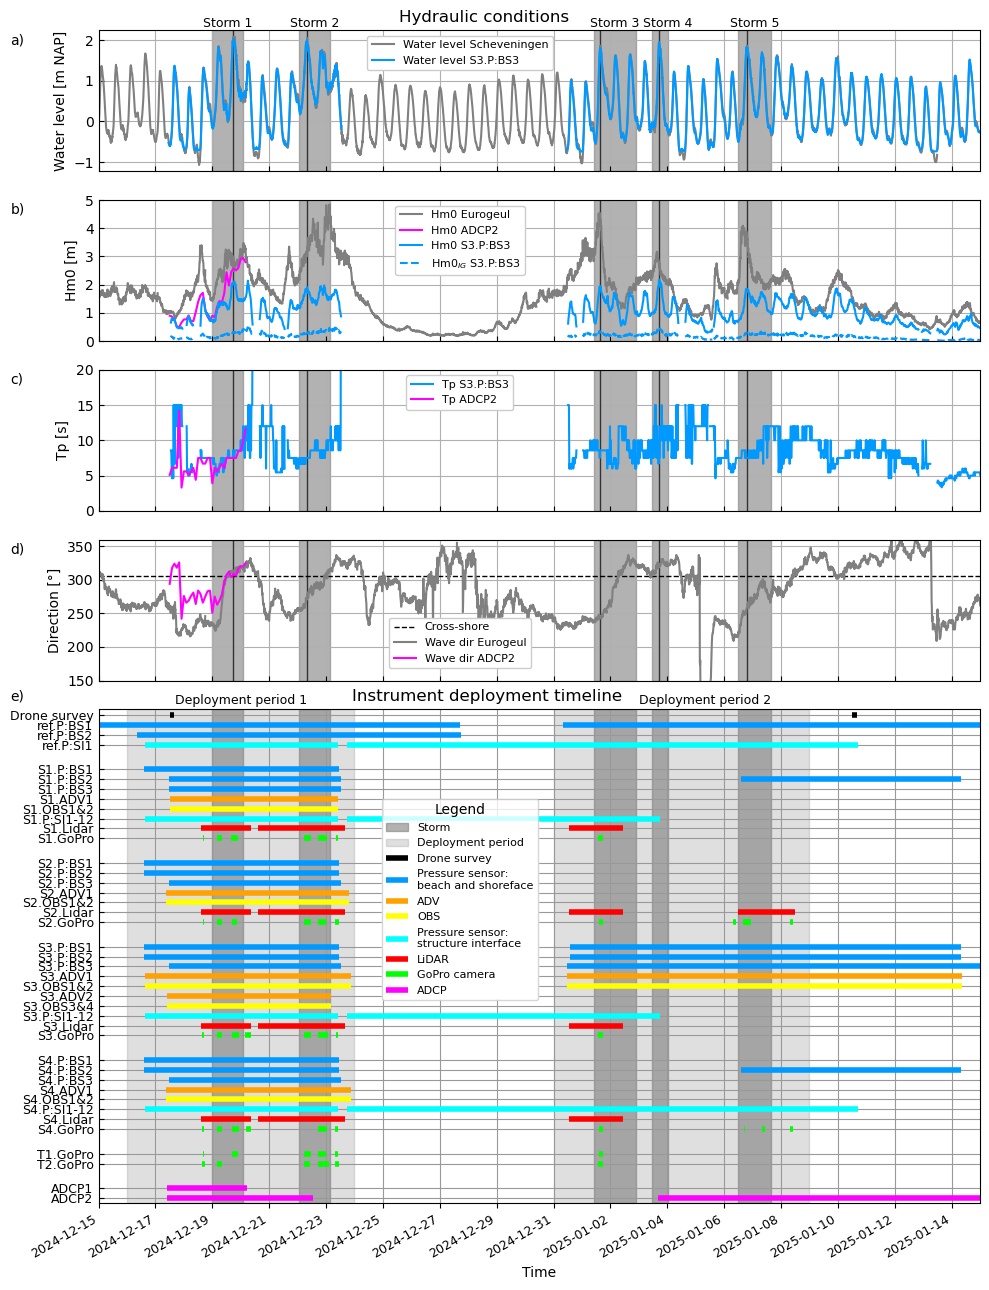

In [26]:
# Helper function to plot a timeline segment and set a single yticklabel
def plot_timeline(ax, t_start_stop, y_pos, color, label):
    ax.hlines(y_pos, t_start_stop[0], t_start_stop[1], colors=color, linewidth=4)
    # Get current yticks and labels
    yticks = list(ax.get_yticks())
    yticklabels = [item.get_text() for item in ax.get_yticklabels()]
    # Add or update the label for y_pos
    if y_pos in yticks:
        idx = yticks.index(y_pos)
        yticklabels[idx] = label
    else:
        yticks.append(y_pos)
        yticklabels.append(label)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)

color_BS    = [0, 0.6,  1]
color_ADV   = [1, 0.63, 0]
color_OBS   = [1, 1,    0]
color_SI    = [0, 1,    1]
color_Lidar = [1, 0,    0]
color_GoPro = [0, 1,    0]
color_ADCP  = [1, 0,    1]

text_size = 9
storm_times = [ (np.datetime64('2024-12-19T00:00'), np.datetime64('2024-12-20T02:00')),
                (np.datetime64('2024-12-22T01:30'), np.datetime64('2024-12-23T03:00')),
                (np.datetime64('2025-01-01T10:00'), np.datetime64('2025-01-02T22:00')),
                (np.datetime64('2025-01-03T11:00'), np.datetime64('2025-01-04T01:00')),
                (np.datetime64('2025-01-06T12:00'), np.datetime64('2025-01-07T16:00'))   ]
peak_times = [ np.datetime64('2024-12-19T17:30'),
               np.datetime64('2024-12-22T07:30'),
               np.datetime64('2025-01-01T15:00'),
               np.datetime64('2025-01-03T17:00'),
               np.datetime64('2025-01-06T19:00')]
deployment_periods = [   (np.datetime64('2024-12-16'), np.datetime64('2024-12-24')),
                         (np.datetime64('2024-12-31T00:00'), np.datetime64('2025-01-09T00:00'))   ]

t_drone1 = [ np.datetime64('2024-12-17T12:00'), np.datetime64('2024-12-17T16:00') ]
t_drone2 = [ np.datetime64('2025-01-10T12:00'), np.datetime64('2025-01-10T16:00') ]

#Make figure -------------------------------------------------------------------------------------------------------
# make a plot with 5 subplots. zs, Hm0, Tp, wave dir, instruments
fig, axs = plt.subplots(5, 1, figsize=(10, 13), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1, 1, 3.5]})
# import matplotlib.gridspec as gridspec

# fig = plt.figure(figsize=(10, 13))
# gs = gridspec.GridSpec(5, 1, height_ratios=[1, 1, 1, 1, 3.5])

# # Example: reduce space above subplot 2, 3, 4 by adjusting 'top' and 'bottom' of their GridSpec slots
# axs[0] = fig.add_subplot(gs[0])
# axs[1] = fig.add_subplot(gs[1])
# axs[2] = fig.add_subplot(gs[2])
# axs[3] = fig.add_subplot(gs[3])
# axs[4] = fig.add_subplot(gs[4])

# Top: zs_rolling vs t_full
for t_i in enumerate(peak_times):
    axs[0].axvline(t_i[1], color=[0.2, 0.2, 0.2], linestyle='-', linewidth=1.0)
axs[0].plot(t_RWS, zs_RWS, label='Water level Scheveningen', color='gray')
axs[0].plot(t_full, zs_rolling, label='Water level S3.P:BS3', color=color_BS)
axs[0].plot(t_full_b, zs_rolling_b, color=color_BS)
for i, (start, end) in enumerate(storm_times):
    axs[0].axvspan(start, end, color='gray', alpha=0.6)
    midpoint = start + (end - start) / 2
    if i == 3: # use spaces to align labels, prevent overlap
        storm_label = '    Storm 4'
    else:
        storm_label = f'Storm {i+1}'
    axs[0].annotate(storm_label, xy=(midpoint, 1.005), xycoords=('data', 'axes fraction'),
        ha='center', va='bottom', fontsize=text_size, color='black')

axs[0].set_ylabel('Water level [m NAP]')
axs[0].legend(loc='upper center', bbox_to_anchor=(0.41, 1), fontsize=8, framealpha=1)
axs[0].grid(True)
axs[0].set_title('Hydraulic conditions                     ') # extra spaces for allignment to left
axs[0].tick_params(axis='x', direction='in')
axs[0].tick_params(axis='y', direction='in')
axs[0].text(-0.1, 0.98, 'a)', transform=axs[0].transAxes, fontsize=10, va='top', ha='left')

# Middle: Hm0 vs t_block
for t_i in enumerate(peak_times):
    axs[1].axvline(t_i[1], color=[0.2, 0.2, 0.2], linestyle='-', linewidth=1.0)
axs[1].plot(t_eurogeul, Hm0_eurogeul, label='Hm0 Eurogeul', color='tab:gray', linestyle='-')
axs[1].plot(df1['datetime'], df1['Hs'], label='Hm0 ADCP2', color=color_ADCP)
axs[1].plot(t_block, Hm0, label='Hm0 S3.P:BS3', color=color_BS)
axs[1].plot(t_block_b, Hm0_b, color=color_BS)
#label='Hm0$_{IG}$'
#label='Hm0$_{\\mathrm{IG}}$'
axs[1].plot(t_block, Hm0_IG, label='Hm0$_{IG}$ S3.P:BS3', linestyle='--', color=color_BS)
axs[1].plot(t_block_b, Hm0_IG_b, linestyle='--', color=color_BS)
for i, (start, end) in enumerate(storm_times):
    axs[1].axvspan(start, end, color='gray', alpha=0.6)
    
axs[1].set_ylabel('Hm0 [m]')
axs[1].legend(loc='upper center', bbox_to_anchor=(0.41, 1), fontsize=8, framealpha=1)
axs[1].grid(True)
# axs[1].set_title('Significant wave height         ')
axs[1].tick_params(axis='x', direction='in')
axs[1].tick_params(axis='y', direction='in')
axs[1].set_ylim(0,5)
axs[1].text(-0.1, 0.98, 'b)', transform=axs[1].transAxes, fontsize=10, va='top', ha='left')

# Bottom: Tp vs t_block
for t_i in enumerate(peak_times):
    axs[2].axvline(t_i[1], color=[0.2, 0.2, 0.2], linestyle='-', linewidth=1.0)
axs[2].plot(t_block, Tp, label='Tp S3.P:BS3', color=color_BS)
axs[2].plot(t_block_b, Tp_b, color=color_BS)
axs[2].plot(df1['datetime'], df1['Tp'], label='Tp ADCP2', color=color_ADCP)

for i, (start, end) in enumerate(storm_times):
    axs[2].axvspan(start, end, color='gray', alpha=0.6)
axs[2].set_ylabel('Tp [s]')
axs[2].set_xlabel('Time')
axs[2].legend(loc='upper center', bbox_to_anchor=(0.41, 1), fontsize=8, framealpha=1)
axs[2].grid(True)
# axs[2].set_title('Peak wave period         ')
axs[2].set_ylim(0,20)
axs[2].tick_params(axis='x', direction='in')
axs[2].tick_params(axis='y', direction='in')
axs[2].text(-0.1, 0.98, 'c)', transform=axs[2].transAxes, fontsize=10, va='top', ha='left')

# Fourth: wave direction
for t_i in enumerate(peak_times):
    axs[3].axvline(t_i[1], color=[0.2, 0.2, 0.2], linestyle='-', linewidth=1.0)
axs[3].axhline(306, color='black', label='Cross-shore', linestyle='--', linewidth=1.0)
axs[3].plot(t_eurogeul, dir_eurogeul1,'-', label='Wave dir Eurogeul', color='gray')
axs[3].plot(df1['datetime'], df1['Dm'], label='Wave dir ADCP2', color=color_ADCP)
# horizontal line at y=306

for i, (start, end) in enumerate(storm_times):
    axs[3].axvspan(start, end, color='gray', alpha=0.6)
       
axs[3].set_ylabel('Direction [°]')
axs[3].legend(loc='lower center', bbox_to_anchor=(0.41, 0.05), fontsize=8, framealpha=1)
axs[3].grid(True)
# axs[3].set_title('Wave Direction         ')
axs[3].tick_params(axis='x', direction='in')
axs[3].tick_params(axis='y', direction='in')
axs[3].set_ylim(150,360)
axs[3].text(-0.1, 0.98, 'd)', transform=axs[3].transAxes, fontsize=10, va='top', ha='left')

# last subplot: instruments -----------------------------------------------------------------------------
ax = axs[4]
ax.set_yticks([])  # remove all yticks
  
# reference
plot_timeline(ax, t_ref_BS1a, 0, color_BS, 'ref.P:BS1')
plot_timeline(ax, t_ref_BS1b, 0, color_BS, 'ref.P:BS1')
plot_timeline(ax, t_ref_BS2a, 1, color_BS, 'ref.P:BS2')

for i in range(1, 10):
    t = globals()[f"t_SI_S4_file{i}"]
    plot_timeline(ax, t, 2, color_SI, 'ref.P:SI1')

# S1: dike-in-dune
y0 = 3.5
plot_timeline(ax, t_S1_BS1a, y0 + 1, color_BS, 'S1.P:BS1')
plot_timeline(ax, t_S1_BS2a, y0 + 2, color_BS, 'S1.P:BS2')
plot_timeline(ax, t_S1_BS2b, y0 + 2, color_BS, 'S1.P:BS2')
plot_timeline(ax, t_S1_BS3a, y0 + 3, color_BS, 'S1.P:BS3')

plot_timeline(ax, t_S1_ADV1, y0 + 4, color_ADV, 'S1.ADV1')
plot_timeline(ax, t_S1_ADV1, y0 + 5, color_OBS, 'S1.OBS1&2')

for i in range(1, 7):
    t = globals()[f"t_SI_S1_file{i}"]
    plot_timeline(ax, t, y0 + 6, color_SI, 'S1.P:SI1-12')
    
plot_timeline(ax, t_lidar1_storm1, y0 + 7, color_Lidar, 'S1.Lidar')
plot_timeline(ax, t_lidar1_storm2, y0 + 7, color_Lidar, 'S1.Lidar')
plot_timeline(ax, t_lidar1_storm3, y0 + 7, color_Lidar, 'S1.Lidar')

for i in range(1, 8):
    t = globals()[f"t_GoPro_S1_{i}"]
    plot_timeline(ax, t, y0 + 8, color_GoPro, 'S1.GoPro')

# S2: sandy dune
y0 = 13 # 2 higher than previous section, for gap
plot_timeline(ax, t_S2_BS1a, y0 + 1, color_BS, 'S2.P:BS1')
plot_timeline(ax, t_S2_BS2a, y0 + 2, color_BS, 'S2.P:BS2')
plot_timeline(ax, t_S2_BS3a, y0 + 3, color_BS, 'S2.P:BS3')

plot_timeline(ax, t_S2_ADV1, y0 + 4, color_ADV, 'S2.ADV1')
plot_timeline(ax, t_S2_ADV1, y0 + 5, color_OBS, 'S2.OBS1&2')

plot_timeline(ax, t_lidar2_storm1, y0 + 6, color_Lidar, 'S2.Lidar')
plot_timeline(ax, t_lidar2_storm2, y0 + 6, color_Lidar, 'S2.Lidar')
plot_timeline(ax, t_lidar2_storm3, y0 + 6, color_Lidar, 'S2.Lidar')
plot_timeline(ax, t_lidar2_storm5, y0 + 6, color_Lidar, 'S2.Lidar')

for i in range(1, 12):
    t = globals()[f"t_GoPro_S2_{i}"]
    plot_timeline(ax, t, y0 + 7, color_GoPro, 'S2.GoPro')

# S3: dike
y0 = 21.5 # 2 higher than previous section, for gap
plot_timeline(ax, t_S3_BS1a, y0 + 1, color_BS, 'S3.P:BS1')
plot_timeline(ax, t_S3_BS1b, y0 + 1, color_BS, 'S3.P:BS1')
plot_timeline(ax, t_S3_BS2a, y0 + 2, color_BS, 'S3.P:BS2')
plot_timeline(ax, t_S3_BS2b, y0 + 2, color_BS, 'S3.P:BS2')
plot_timeline(ax, t_S3_BS3a, y0 + 3, color_BS, 'S3.P:BS3')
plot_timeline(ax, t_S3_BS3b, y0 + 3, color_BS, 'S3.P:BS3')

plot_timeline(ax, t_S3_ADV1a, y0 + 4, color_ADV, 'S3.ADV1')
plot_timeline(ax, t_S3_ADV1b, y0 + 4, color_ADV, 'S3.ADV1')
plot_timeline(ax, t_S3_ADV1a, y0 + 5, color_OBS, 'S3.OBS1&2')
plot_timeline(ax, t_S3_ADV1b, y0 + 5, color_OBS, 'S3.OBS1&2')
plot_timeline(ax, t_S3_ADV2, y0 + 6, color_ADV, 'S3.ADV2')
plot_timeline(ax, t_S3_ADV2, y0 + 7, color_OBS, 'S3.OBS3&4')

for i in range(1, 7):
    t = globals()[f"t_SI_S3_file{i}"]
    plot_timeline(ax, t, y0 + 8, color_SI, 'S3.P:SI1-12')

plot_timeline(ax, t_lidar1_storm1, y0 + 9, color_Lidar, 'S3.Lidar')
plot_timeline(ax, t_lidar1_storm2, y0 + 9, color_Lidar, 'S3.Lidar')
plot_timeline(ax, t_lidar1_storm3, y0 + 9, color_Lidar, 'S3.Lidar')

for i in range(1, 9):
    t = globals()[f"t_GoPro_S3_{i}"]
    plot_timeline(ax, t, y0 + 10, color_GoPro, 'S3.GoPro')

# S4 Wall-in-dune
y0 = 33 # 2 higher than previous section, for gap
plot_timeline(ax, t_S4_BS1a, y0 + 1, color_BS, 'S4.P:BS1')
plot_timeline(ax, t_S4_BS2a, y0 + 2, color_BS, 'S4.P:BS2')
plot_timeline(ax, t_S4_BS2b, y0 + 2, color_BS, 'S4.P:BS2')
plot_timeline(ax, t_S4_BS3a, y0 + 3, color_BS, 'S4.P:BS3')

plot_timeline(ax, t_S4_ADV1, y0 + 4, color_ADV, 'S4.ADV1')
plot_timeline(ax, t_S4_ADV1, y0 + 5, color_OBS, 'S4.OBS1&2')

for i in range(1, 10):
    t = globals()[f"t_SI_S4_file{i}"]
    plot_timeline(ax, t, y0 + 6, color_SI, 'S4.P:SI1-12')

plot_timeline(ax, t_lidar1_storm1, y0 + 7, color_Lidar, 'S4.Lidar')
plot_timeline(ax, t_lidar1_storm2, y0 + 7, color_Lidar, 'S4.Lidar')
plot_timeline(ax, t_lidar1_storm3, y0 + 7, color_Lidar, 'S4.Lidar')

for i in range(1, 12):
    t = globals()[f"t_GoPro_S4_{i}"]
    plot_timeline(ax, t, y0 + 8, color_GoPro, 'S4.GoPro')

# T1, T2
y0 = 42.5
for i in range(1, 8):
    t = globals()[f"t_GoPro_T1_{i}"]
    plot_timeline(ax, t, y0+1, color_GoPro, 'T1.GoPro')

for i in range(1, 8):
    t = globals()[f"t_GoPro_T2_{i}"]
    plot_timeline(ax, t, y0 + 2, color_GoPro, 'T2.GoPro')

# ADCPs
y0 = 46
plot_timeline(ax, t_ADCP2, y0 + 1, color_ADCP, 'ADCP1')
plot_timeline(ax, t_ADCP1a, y0 + 2, color_ADCP, 'ADCP2')
plot_timeline(ax, t_ADCP1b, y0 + 2, color_ADCP, 'ADCP2')

# Drone surveys
y0 = 49.5
plot_timeline(ax, t_drone1, -1, [0, 0, 0], 'Drone survey')
plot_timeline(ax, t_drone2, -1, [0, 0, 0], 'Drone survey')

# plot for each of the 5 storms a semi-transparent rectangle
for i, (start, end) in enumerate(storm_times):
    label = 'Storm' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.6, label=label)

# plot for each of the 2 deployment periods a semi-transparent rectangle (no loop, two lines)
ax.axvspan(deployment_periods[0][0], deployment_periods[0][1], color='gray', alpha=0.25, label='Deployment period')
midpoint = deployment_periods[0][0] + (deployment_periods[0][1] - deployment_periods[0][0]) / 2
ax.annotate('Deployment period 1', xy=(midpoint, 1.005), xycoords=('data', 'axes fraction'),
            ha='center', va='bottom', fontsize=text_size, color='black')

ax.axvspan(deployment_periods[1][0], deployment_periods[1][1], color='gray', alpha=0.25)
midpoint = deployment_periods[1][0] + (deployment_periods[1][1] - deployment_periods[1][0]) / 2
ax.annotate('            Deployment period 2', xy=(midpoint, 1.005), xycoords=('data', 'axes fraction'),
            ha='center', va='bottom', fontsize=text_size, color='black')

# Dummy legend entries
ax.hlines(np.nan, t_ref_BS1a[0], t_ref_BS1a[1], [0, 0, 0], linewidth=4, label='Drone survey')
ax.hlines(np.nan, t_ref_BS1a[0], t_ref_BS1a[1], color_BS, linewidth=4, label='Pressure sensor: \nbeach and shoreface')
ax.hlines(np.nan, t_ref_BS1a[0], t_ref_BS1a[1], color_ADV, linewidth=4, label='ADV')
ax.hlines(np.nan, t_ref_BS1a[0], t_ref_BS1a[1], color_OBS, linewidth=4, label='OBS')
ax.hlines(np.nan, t_ref_BS1a[0], t_ref_BS1a[1], color_SI, linewidth=4, label='Pressure sensor: \nstructure interface')
ax.hlines(np.nan, t_ref_BS1a[0], t_ref_BS1a[1], color_Lidar, linewidth=4, label='LiDAR')
ax.hlines(np.nan, t_ref_BS1a[0], t_ref_BS1a[1], color_GoPro, linewidth=4, label='GoPro camera')
ax.hlines(np.nan, t_ref_BS1a[0], t_ref_BS1a[1], color_ADCP, linewidth=4, label='ADCP')

# Make legend
#ax.legend(loc='upper center', bbox_to_anchor=(0.41, 0.77), fontsize=8, framealpha=1)
leg = ax.legend(loc='upper center', bbox_to_anchor=(0.41, 0.83), fontsize=8, framealpha=0.8, title='Legend')
plt.draw()  # Needed to ensure the legend is drawn and has a position

# Draw a white rectangle behind the legend to cover overlapping lines (slightly smaller than legend,keep everything exept blue bar invisible)
bbox = leg.get_window_extent()    # Get the legend's bounding box in display coordinates

# Transform to axes coordinates
inv = ax.transAxes.inverted()
bbox_ax = mtransforms.Bbox(inv.transform(bbox))

# Draw a rectangle at the legend's position
rect = plt.Rectangle((bbox_ax.x0+0.012, bbox_ax.y0+0.1), bbox_ax.width-0.024, bbox_ax.height-0.142,
                     transform=ax.transAxes, color='white', zorder=leg.get_zorder()-1, clip_on=False)
ax.add_patch(rect)

ax.legend(loc='upper center', bbox_to_anchor=(0.41, 0.83), fontsize=8, framealpha=0.8, title='Legend')   # Redraw the legend on top

# General subplot formatting

ax.set_xlim([np.datetime64('2024-12-15'), np.datetime64('2025-01-15')])
ax.set_xlabel('Time')
ax.set_ylim(-1.6, 48.5)
ax.invert_yaxis()  # switch ydirection
ax.tick_params(axis='y', labelsize=9)   # set ytick label size to fontsize 9
ax.set_title('Instrument deployment timeline                    ') # extra spaces for allignment to left. pad to raise the title
axs[4].text(-0.1, 1.04, 'e)', transform=axs[4].transAxes, fontsize=10, va='top', ha='left')

#fig.suptitle('Instrument deployment timeline', y=0.96) # Move the title above the annotations
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # Set xticks every 2 days
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(color=[0.6, 0.6, 0.6])
fig.autofmt_xdate()
ax.tick_params(axis='x', labelsize=9)  
#ax.tick_params(axis='x', direction='inout')
ax.tick_params(axis='y', direction='in')

# decrease white space between subplots
plt.tight_layout(h_pad=0.6)  # Decrease h_pad for less vertical space
fig.savefig('Instrument timeline 2.png', dpi=300, bbox_inches='tight')  # High-res PNG
fig.savefig('Instrument timeline 4.pdf', bbox_inches='tight')           # PDF
plt.show()

In [16]:
bbox_ax.height

np.float64(0.5007297464440321)

In [17]:
nc_path = r'O:\HybridDune experiment\data waterinfo etc\RWS reactie\Waterlevel_SCHEVNGN.nc'
with xr.open_dataset(nc_path) as ds:
    t_RWS = ds.t.values[2200:6000]
    zs_RWS = ds.waterlevel.values[2200:6000]/100 

    #print t0,t_end, zs_min and zs_max
    t0 = t_RWS[0]
    t_end = t_RWS[-1]
    zs_min = np.nanmin(zs_RWS)
    zs_max = np.nanmax(zs_RWS)
    print(f'RWS Scheveningen waterlevel data from {t0} to {t_end}')
    print(f'Waterlevel min: {zs_min} m NAP, max: {zs_max} m NAP')
    

RWS Scheveningen waterlevel data from 2024-12-16T06:40:00.000000000 to 2025-01-11T15:50:00.000000000
Waterlevel min: -1.07 m NAP, max: 2.08 m NAP
